In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

df = pd.read_csv("../data/kc_house_data.csv")


In [58]:
#Shape, info, describe
print(df.shape)
print(df.info())
print(df.describe())

(21613, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64

In [59]:
print(df.isna().sum())

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


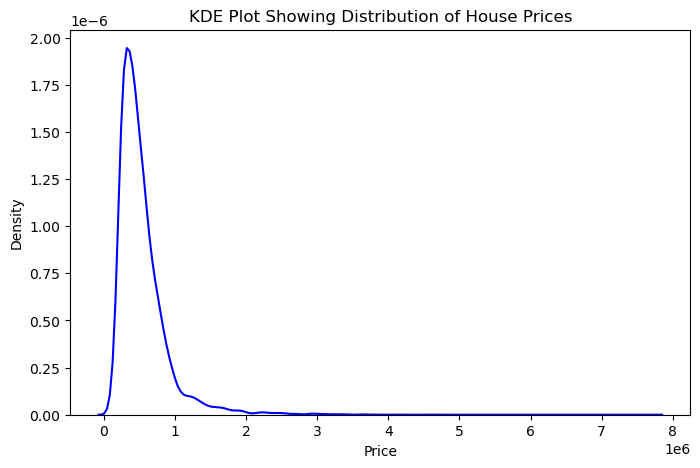

Skewness of the dataset is: 4.024069144684712


In [68]:
#Distribution of price — is it skewed?

plt.figure(figsize=(8, 5))
sns.kdeplot(df['price'], color="blue")
plt.title("KDE Plot Showing Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Density")
plt.savefig("skewwed_price_graph")
plt.show()

skewness_value = df['price'].skew()
print(f"Skewness of the dataset is: {skewness_value}")

#yes it is positively skewed


zipcode
98039    2.160607e+06
98004    1.355927e+06
98040    1.194230e+06
98112    1.095499e+06
98102    9.012583e+05
98109    8.796236e+05
98105    8.628252e+05
98006    8.596848e+05
98119    8.494480e+05
98005    8.101649e+05
Name: price, dtype: float64


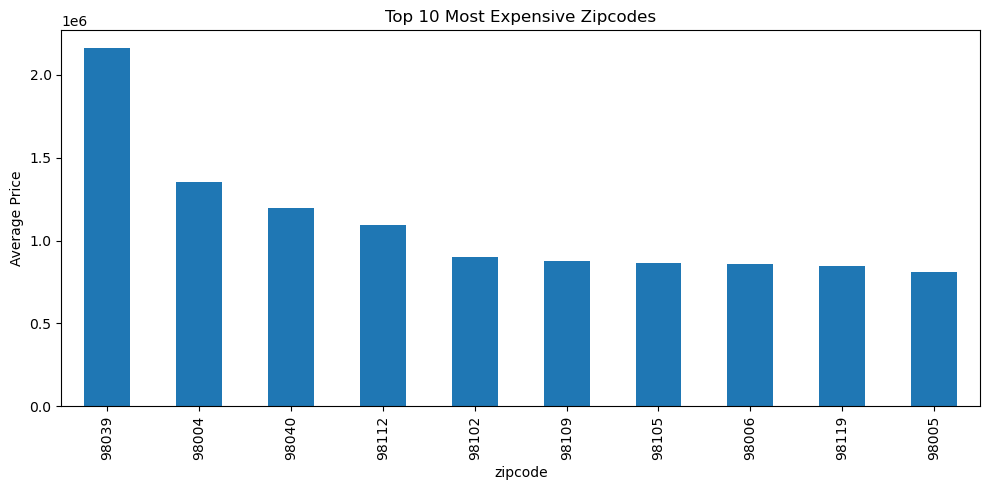

In [61]:
#Top 10 most expensive zipcodes
top_zipcodes = df.groupby("zipcode")["price"].mean().sort_values(ascending=False).head(10)
print(top_zipcodes)
top_zipcodes.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Most Expensive Zipcodes")
plt.ylabel("Average Price")
plt.tight_layout()
plt.savefig("top_zipcodes.png")
plt.show()

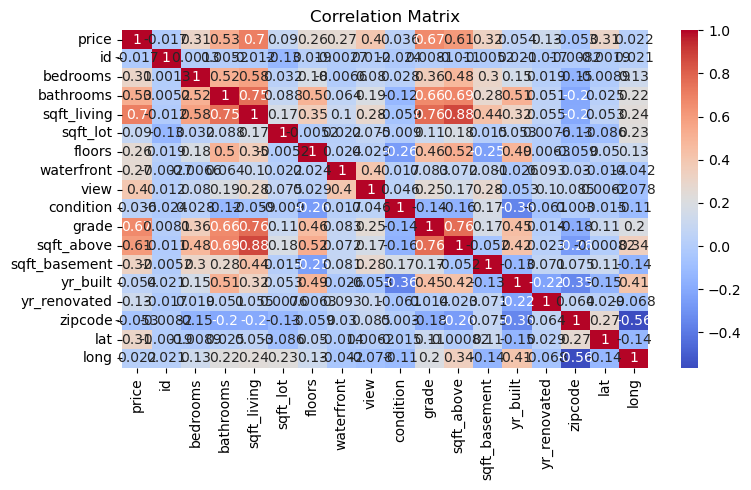

In [62]:
##Correlation heatmap of all numeric columns — which features correlate most with price?
plt.figure(figsize=(8,5))
correlation = df[['price','id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long']].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png")
plt.show()

#sqft_living and price have a +0.7 correlation and grade has a +0.67 correlation with price. two are the highest so far

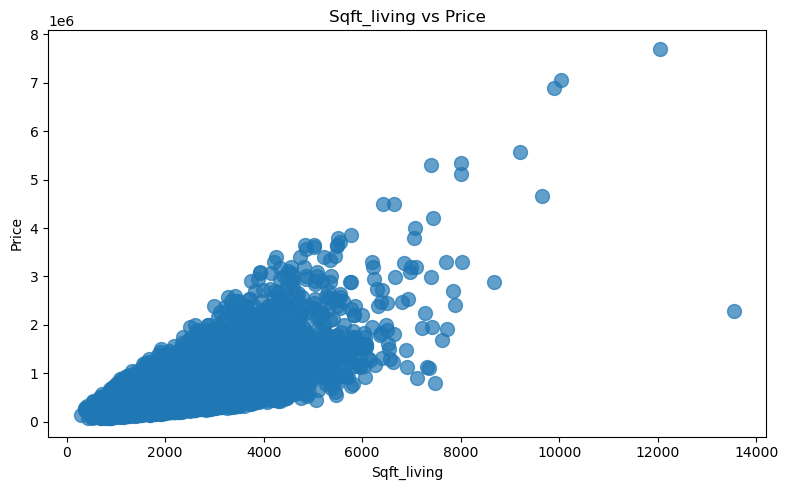

In [63]:
#Scatter plots: sqft_living vs price
plt.figure(figsize=(8, 5))
plt.scatter(df['sqft_living'], df['price'], alpha=0.7, s=100)
plt.title("Sqft_living vs Price")
plt.xlabel("Sqft_living")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("sqft_living_price.png")
plt.show()


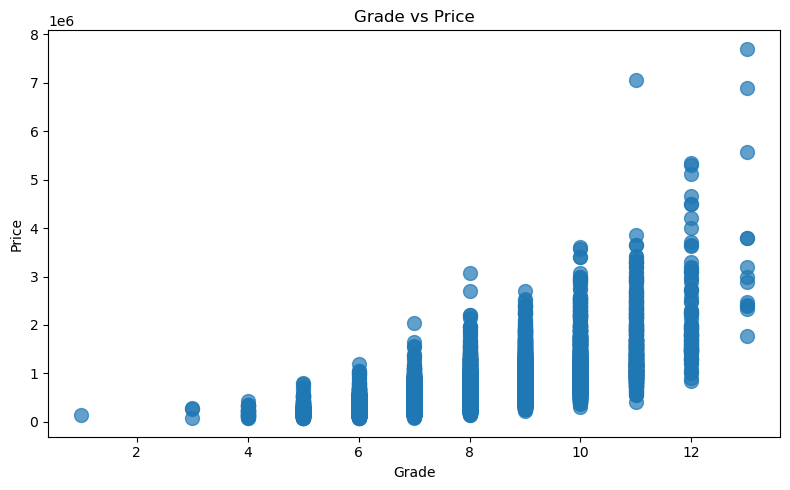

In [64]:
# grade vs price
plt.figure(figsize=(8, 5))
plt.scatter(df['grade'], df['price'], alpha=0.7, s=100)
plt.title("Grade vs Price")
plt.xlabel("Grade")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("grade_price_scatter.png")
plt.show()



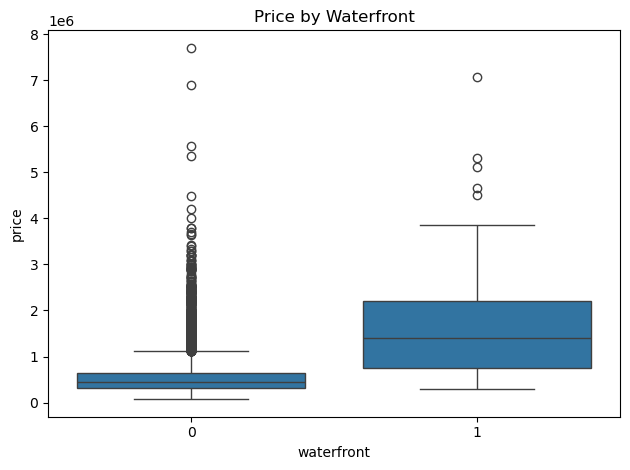

In [65]:
#Price distribution by waterfront using boxplot
sns.boxplot(x="waterfront", y="price", data=df)
plt.title("Price by Waterfront")
plt.tight_layout()
plt.savefig("price_by_distrubtion_boxplot.png")
plt.show()


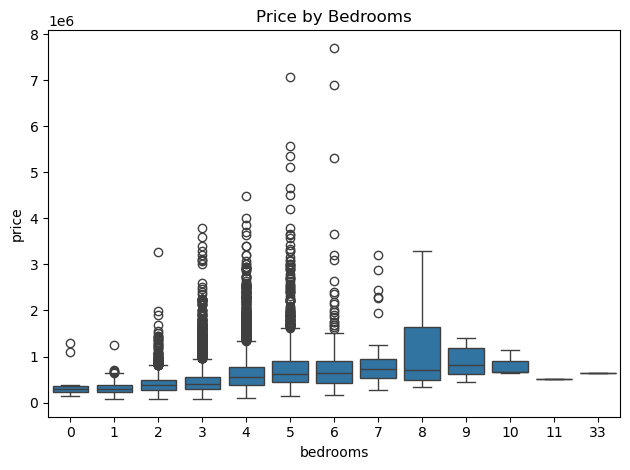

In [66]:
#Price distribution by number of bedrooms using boxplot
sns.boxplot(x="bedrooms", y="price", data=df)
plt.title("Price by Bedrooms")
plt.tight_layout()
plt.savefig("price_by_bedroom_boxplot.png")
plt.show()

In [ ]:
#Write 5 observations — what drives house prices in this dataset?

# Observation 1: House prices are heavily right-skewed — most homes sell in a lower 
# price range while a small number of luxury properties pull the average upward.

# Observation 2: sqft_living has the strongest correlation with price (+0.70), 
# confirming that living space size is the single biggest driver of value.

# Observation 3: Grade (construction/design quality) is the second strongest 
# predictor at +0.67, suggesting build quality matters almost as much as size.

# Observation 4: The top 10 zipcodes show massive price variation by location alone 
# — geography is a major hidden driver not captured by physical house features.

# Observation 5: Waterfront properties show a clear price premium with much higher 
# medians and outliers, while bedroom count alone is a weaker predictor than expected.